In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
from tqdm import tqdm

In [59]:
data=np.load('/home/kjaworski/Pulpit/Temporal_thermal_imaging/all_data_extrapolated/param_fbh_gaussian_size5mm_depth10pct_thickness6mm.npz',allow_pickle=True)
bscan=data['data'][:,200,:]
mask=data['mask'][200,:]
bscan=torch.from_numpy(bscan).float()
mask=torch.from_numpy(mask).float()

bscan_2=data['data'][:,400,:]
mask_2=data['mask'][400,:]
bscan_2=torch.from_numpy(bscan_2).float()
mask_2=torch.from_numpy(mask_2).float()

In [60]:
from helper_functions.helper_functions import NoiseAddition,RandomGaussianBlur,DefectSlopeDropout

In [61]:
noise=NoiseAddition(sigma_min=0.39,sigma_max=0.4) # Max noise
blur=RandomGaussianBlur(p=1,kernel_sizes=(7,9),sigma_range=(2.9,3.0)) # Max blur
drop=DefectSlopeDropout(p=1)

In [62]:
data['meta']

array([['time', '15/07/2025 21:11:19'],
       ['lamp_power', '200'],
       ['lamp_power_units', 'W'],
       ['T1', '4'],
       ['T1_units', 'frames'],
       ['T2', '30'],
       ['T2_units', 'frames'],
       ['T3', '750'],
       ['T3_units', 'frames'],
       ['fps', '30.0'],
       ['fps_units', 'frames/s'],
       ['height', '512'],
       ['height_units', 'pixels'],
       ['width', '512'],
       ['width_units', 'pixels'],
       ['sequence_length', '784'],
       ['sequence_length_units', 'frames'],
       ['working_distance', '200.0'],
       ['working_distance_units', 'mm'],
       ['thickness', '0.006'],
       ['thickness_units', 'm'],
       ['size_X', '0.1'],
       ['size_X_units', 'm'],
       ['size_Y', '0.1'],
       ['size_Y_units', 'm'],
       ['thermal_conductivity', '2.0'],
       ['thermal_conductivity_units', 'W/(m·K)'],
       ['density', '1600.0'],
       ['density_units', 'kg/m^3'],
       ['specific_heat', '700.0'],
       ['specific_heat_units', 'J/(kg

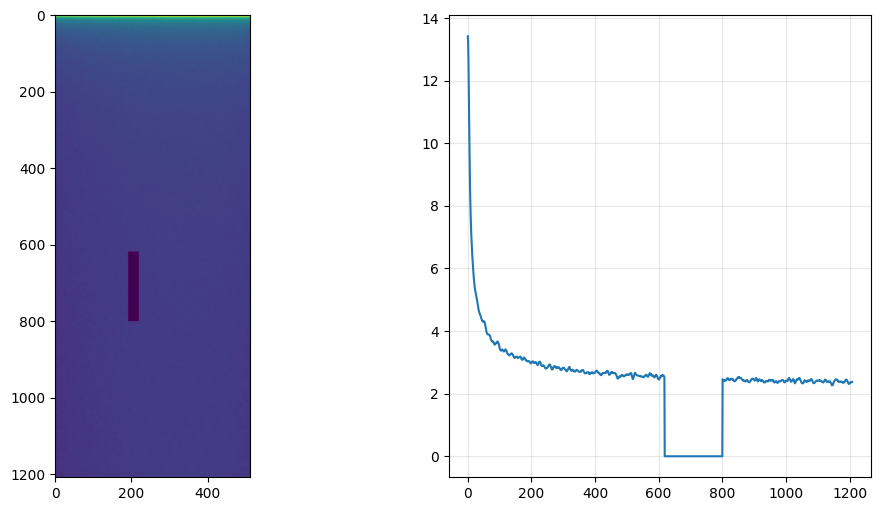

In [64]:
b_sca,mask=noise(bscan,mask)
b_sca,mask=blur(b_sca,mask)
b_sca,mask=drop(b_sca,mask)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(b_sca.detach().cpu())

plt.subplot(1,2,2)
plt.plot(b_sca[:,200].detach().cpu())
plt.grid(alpha=0.3)